## Plotting routine for the analysis

In [47]:
# Imports packages
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import ttest_1samp
import matplotlib.colors as mcolors
import matplotlib.tri as mtri

In [48]:
# Load the data
data_file = "../LessOzone_2000-2005_2d.nc"
grid_file = "../icon_grid_G.nc"
data = xr.open_dataset(data_file)
grid = xr.open_dataset(grid_file)

# Variable & Time
VariableName = "rsus"
time = "2000-02-01T00:00:00.000000000"
# Please recognize that 2000 is 1989 (11 year shift)

# Labels
title = "Incoming Shortwave Radiation – 1989"
colorbarlabel = "W/m^2"

# Design
colormap = "Reds"


In [49]:
# ATTENTION: Only run once!
date_floats = data["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
data = (data.assign_coords(time=date_dt))

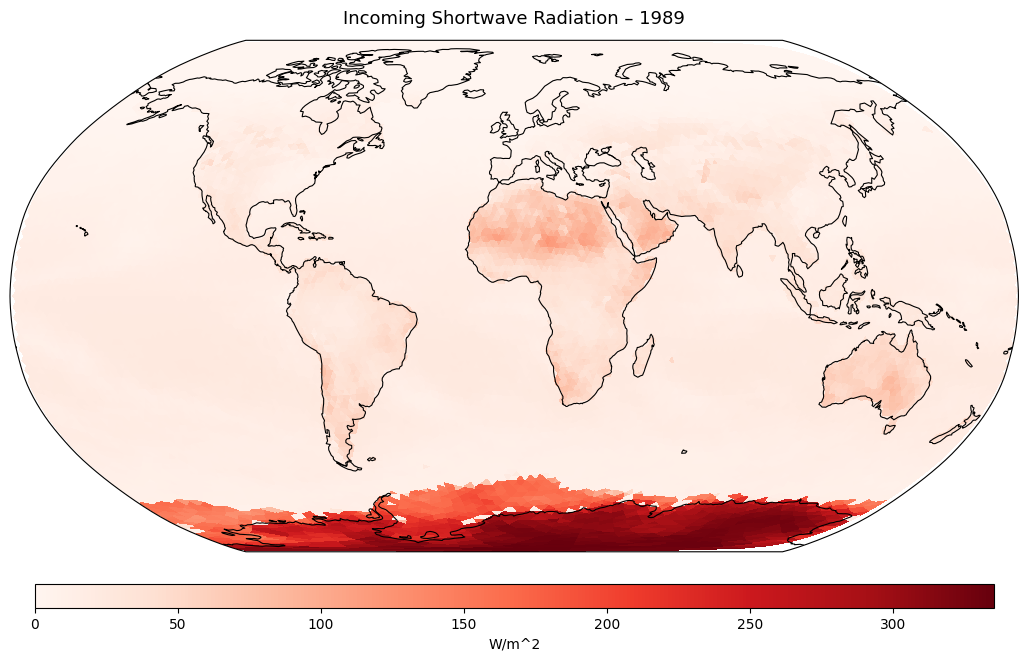

In [50]:

# Zu plottende Variable und Zeitschritt anpassen
values = data[VariableName].sel(time=time).values  # ggf. auch level=0 etc.

# ── Gitterpunkte (Eckpunkte der Dreiecke) ──────────────────────────────────────
vlon = np.rad2deg(grid["vlon"].values)   # Länge der Vertices
vlat = np.rad2deg(grid["vlat"].values)   # Breite der Vertices

# vertex_of_cell: Shape (3, ncells), 1-basiert → 0-basiert
voc = grid["vertex_of_cell"].values - 1  # Shape: (3, ncells)
triangles = voc.T                         # Shape: (ncells, 3)

# ── Triangulation & Antimeridian-Maske ────────────────────────────────────────
triang = mtri.Triangulation(vlon, vlat, triangles)

x0 = vlon[triangles[:, 0]]
x1 = vlon[triangles[:, 1]]
x2 = vlon[triangles[:, 2]]
bad = (np.abs(x0 - x1) > 180) | (np.abs(x1 - x2) > 180) | (np.abs(x0 - x2) > 180)
triang.set_mask(bad)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines(resolution="110m", linewidth=0.8, color="black")
ax.set_title(title, fontsize=13, pad=12)

tc = ax.tripcolor(
    triang,
    values,
    cmap=colormap,
    transform=ccrs.PlateCarree(),
    shading="flat",    # jedes Dreieck einfarbig (= echte ICON-Zellen)
    rasterized=True,   # bessere Performance & saubere Vektorgrafik
)

plt.colorbar(
    tc, ax=ax,
    orientation="horizontal",
    pad=0.05,
    aspect=40,
    label=colorbarlabel,
    shrink=0.7,
)

plt.tight_layout()
#plt.savefig("icon_plot.png", dpi=300, bbox_inches="tight")
plt.show()